In [1]:
import polars as pl

In [2]:
df = pl.read_parquet("benchmark_results/*")
df

dataset,n_train,n_test,series_length,n_classes,model,run,accuracy,time
str,i64,i64,i64,i64,str,i64,f64,f64
"""ACSF1""",100,100,1460,10,"""autotsc""",0,0.89,453.050656
"""ACSF1""",100,100,1460,10,"""hivecotev2""",0,0.86,230.081047
"""ACSF1""",100,100,1460,10,"""multirocket""",0,0.89,19.04684
"""Adiac""",390,391,176,37,"""autotsc""",0,0.831202,323.040018
"""Adiac""",390,391,176,37,"""hivecotev2""",0,0.803069,264.239369
…,…,…,…,…,…,…,…,…
"""Wine""",57,54,234,2,"""multirocket""",0,0.907407,0.322627
"""Worms""",181,77,900,5,"""hivecotev2""",0,0.753247,175.228939
"""Worms""",181,77,900,5,"""multirocket""",0,0.727273,0.974858


In [3]:
stats_pivot = df.pivot(values="accuracy", index="dataset", columns="model").drop_nulls()
stats_pivot

/tmp/ipykernel_2026864/2481188341.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  stats_pivot = df.pivot(values="accuracy", index="dataset", columns="model").drop_nulls()


dataset,autotsc,hivecotev2,multirocket
str,f64,f64,f64
"""ACSF1""",0.89,0.86,0.89
"""Adiac""",0.831202,0.803069,0.83376
"""AllGestureWiimoteX""",0.76,0.737143,0.758571
"""AllGestureWiimoteY""",0.785714,0.752857,0.777143
"""AllGestureWiimoteZ""",0.748571,0.748571,0.765714
…,…,…,…
"""MoteStrain""",0.958466,0.947284,0.944888
"""PowerCons""",1.0,0.983333,0.983333
"""ProximalPhalanxOutlineAgeGroup""",0.834146,0.863415,0.858537


In [4]:
models = df["model"].unique().to_list()
P = stats_pivot.select(models).to_numpy()

(<Figure size 600x220 with 1 Axes>, <Axes: >)

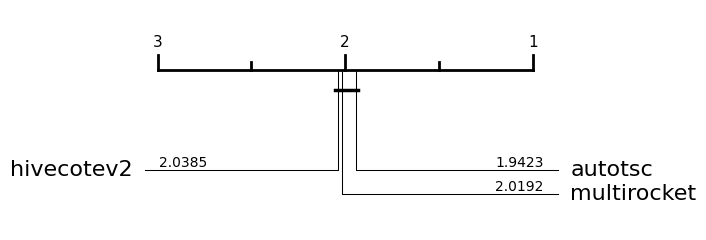

In [5]:
from aeon.visualisation import plot_critical_difference

plot_critical_difference(P, models)

In [6]:
#import ray
#ray.shutdown()